# Analyse Exploratoire des Données (EDA)

Ce notebook a pour objectif de comprendre la structure du dataset avant toute modélisation.
Une bonne exploration permet d'identifier les features les plus discriminantes pour le churn,
de repérer les problèmes de qualité et de justifier les choix de preprocessing qui suivront.

**Dataset :** Customer Churn Prediction Business Dataset (Kaggle - miadul)  
**Observations :** 10 000 clients  
**Variables :** 32 colonnes (comportementales, financières, support, marketing)

In [8]:
import sys,os
print(os.getcwd())

/mnt/d/Etude/Master cours/Projet/Data_Science/Projet_Data_Science


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data.loader import load_raw, get_feature_groups

# Style cohérent pour tous les graphiques du projet
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

df = load_raw()
df.head(3)

Dataset chargé : 10,000 lignes, 32 colonnes


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0


## 1. Vue d'ensemble du dataset

In [2]:
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\nTypes de données :")
print(df.dtypes.value_counts())
print(f"\nMémoire utilisée : {df.memory_usage(deep=True).sum() / 1024:.1f} Ko")

Dimensions : 10,000 lignes × 32 colonnes

Types de données :
int64      14
object     12
float64     6
Name: count, dtype: int64

Mémoire utilisée : 7981.5 Ko


In [3]:
# Valeurs manquantes — complaint_type est la seule colonne concernée.
# Ces NaN correspondent aux clients n'ayant jamais soumis de plainte,
# ce qui est une information en soi et ne doit pas être imputé par la moyenne.
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct}).query('count > 0')
print("Colonnes avec valeurs manquantes :")
display(missing_df)

Colonnes avec valeurs manquantes :


,count,pct
complaint_type,2045,20.45


## 2. Distribution de la variable cible — Churn

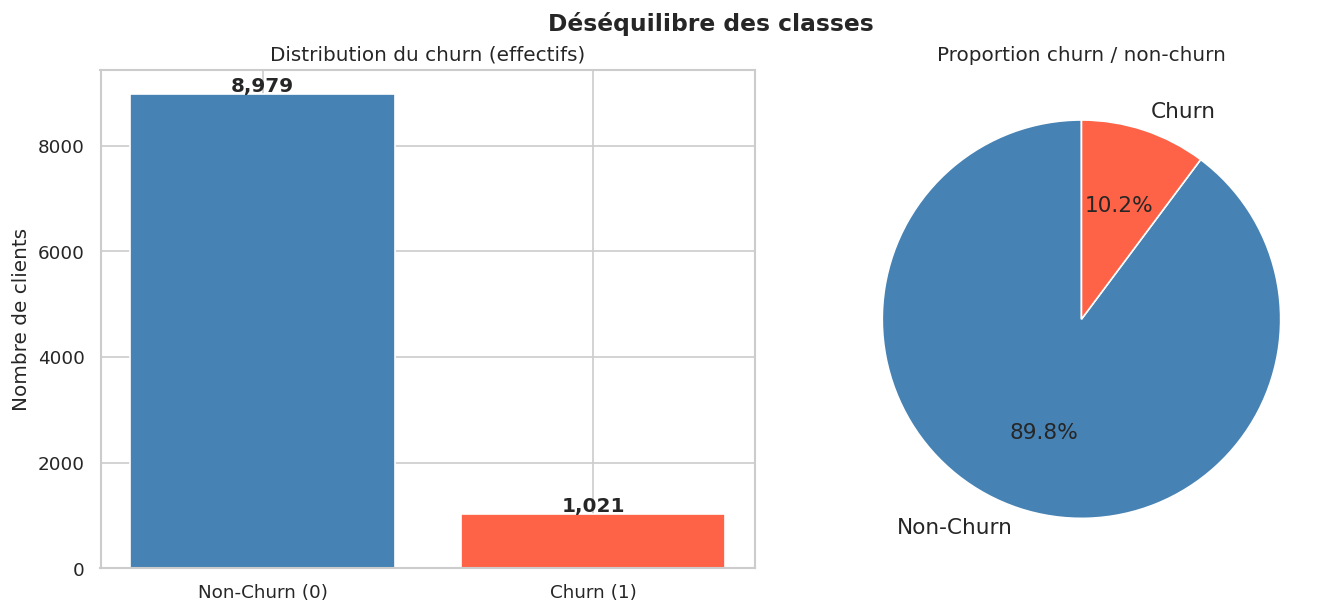

Taux de churn : 10.2%
Le déséquilibre est modéré (~10%). On utilisera class_weight='balanced' ou SMOTE.


In [9]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Comptage brut
bars = axes[0].bar(['Non-Churn (0)', 'Churn (1)'], churn_counts.values,
                   color=['steelblue', 'tomato'], edgecolor='white')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Distribution du churn (effectifs)')
axes[0].set_ylabel('Nombre de clients')

# Proportions
axes[1].pie(churn_pct.values, labels=['Non-Churn', 'Churn'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Proportion churn / non-churn')

plt.tight_layout()
plt.suptitle('Déséquilibre des classes', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('data/processed/fig_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"Taux de churn : {churn_pct[1]:.1f}%")
print("Le déséquilibre est modéré (~10%). On utilisera class_weight='balanced' ou SMOTE.")

## 3. Variables numériques — distributions et liens avec le churn

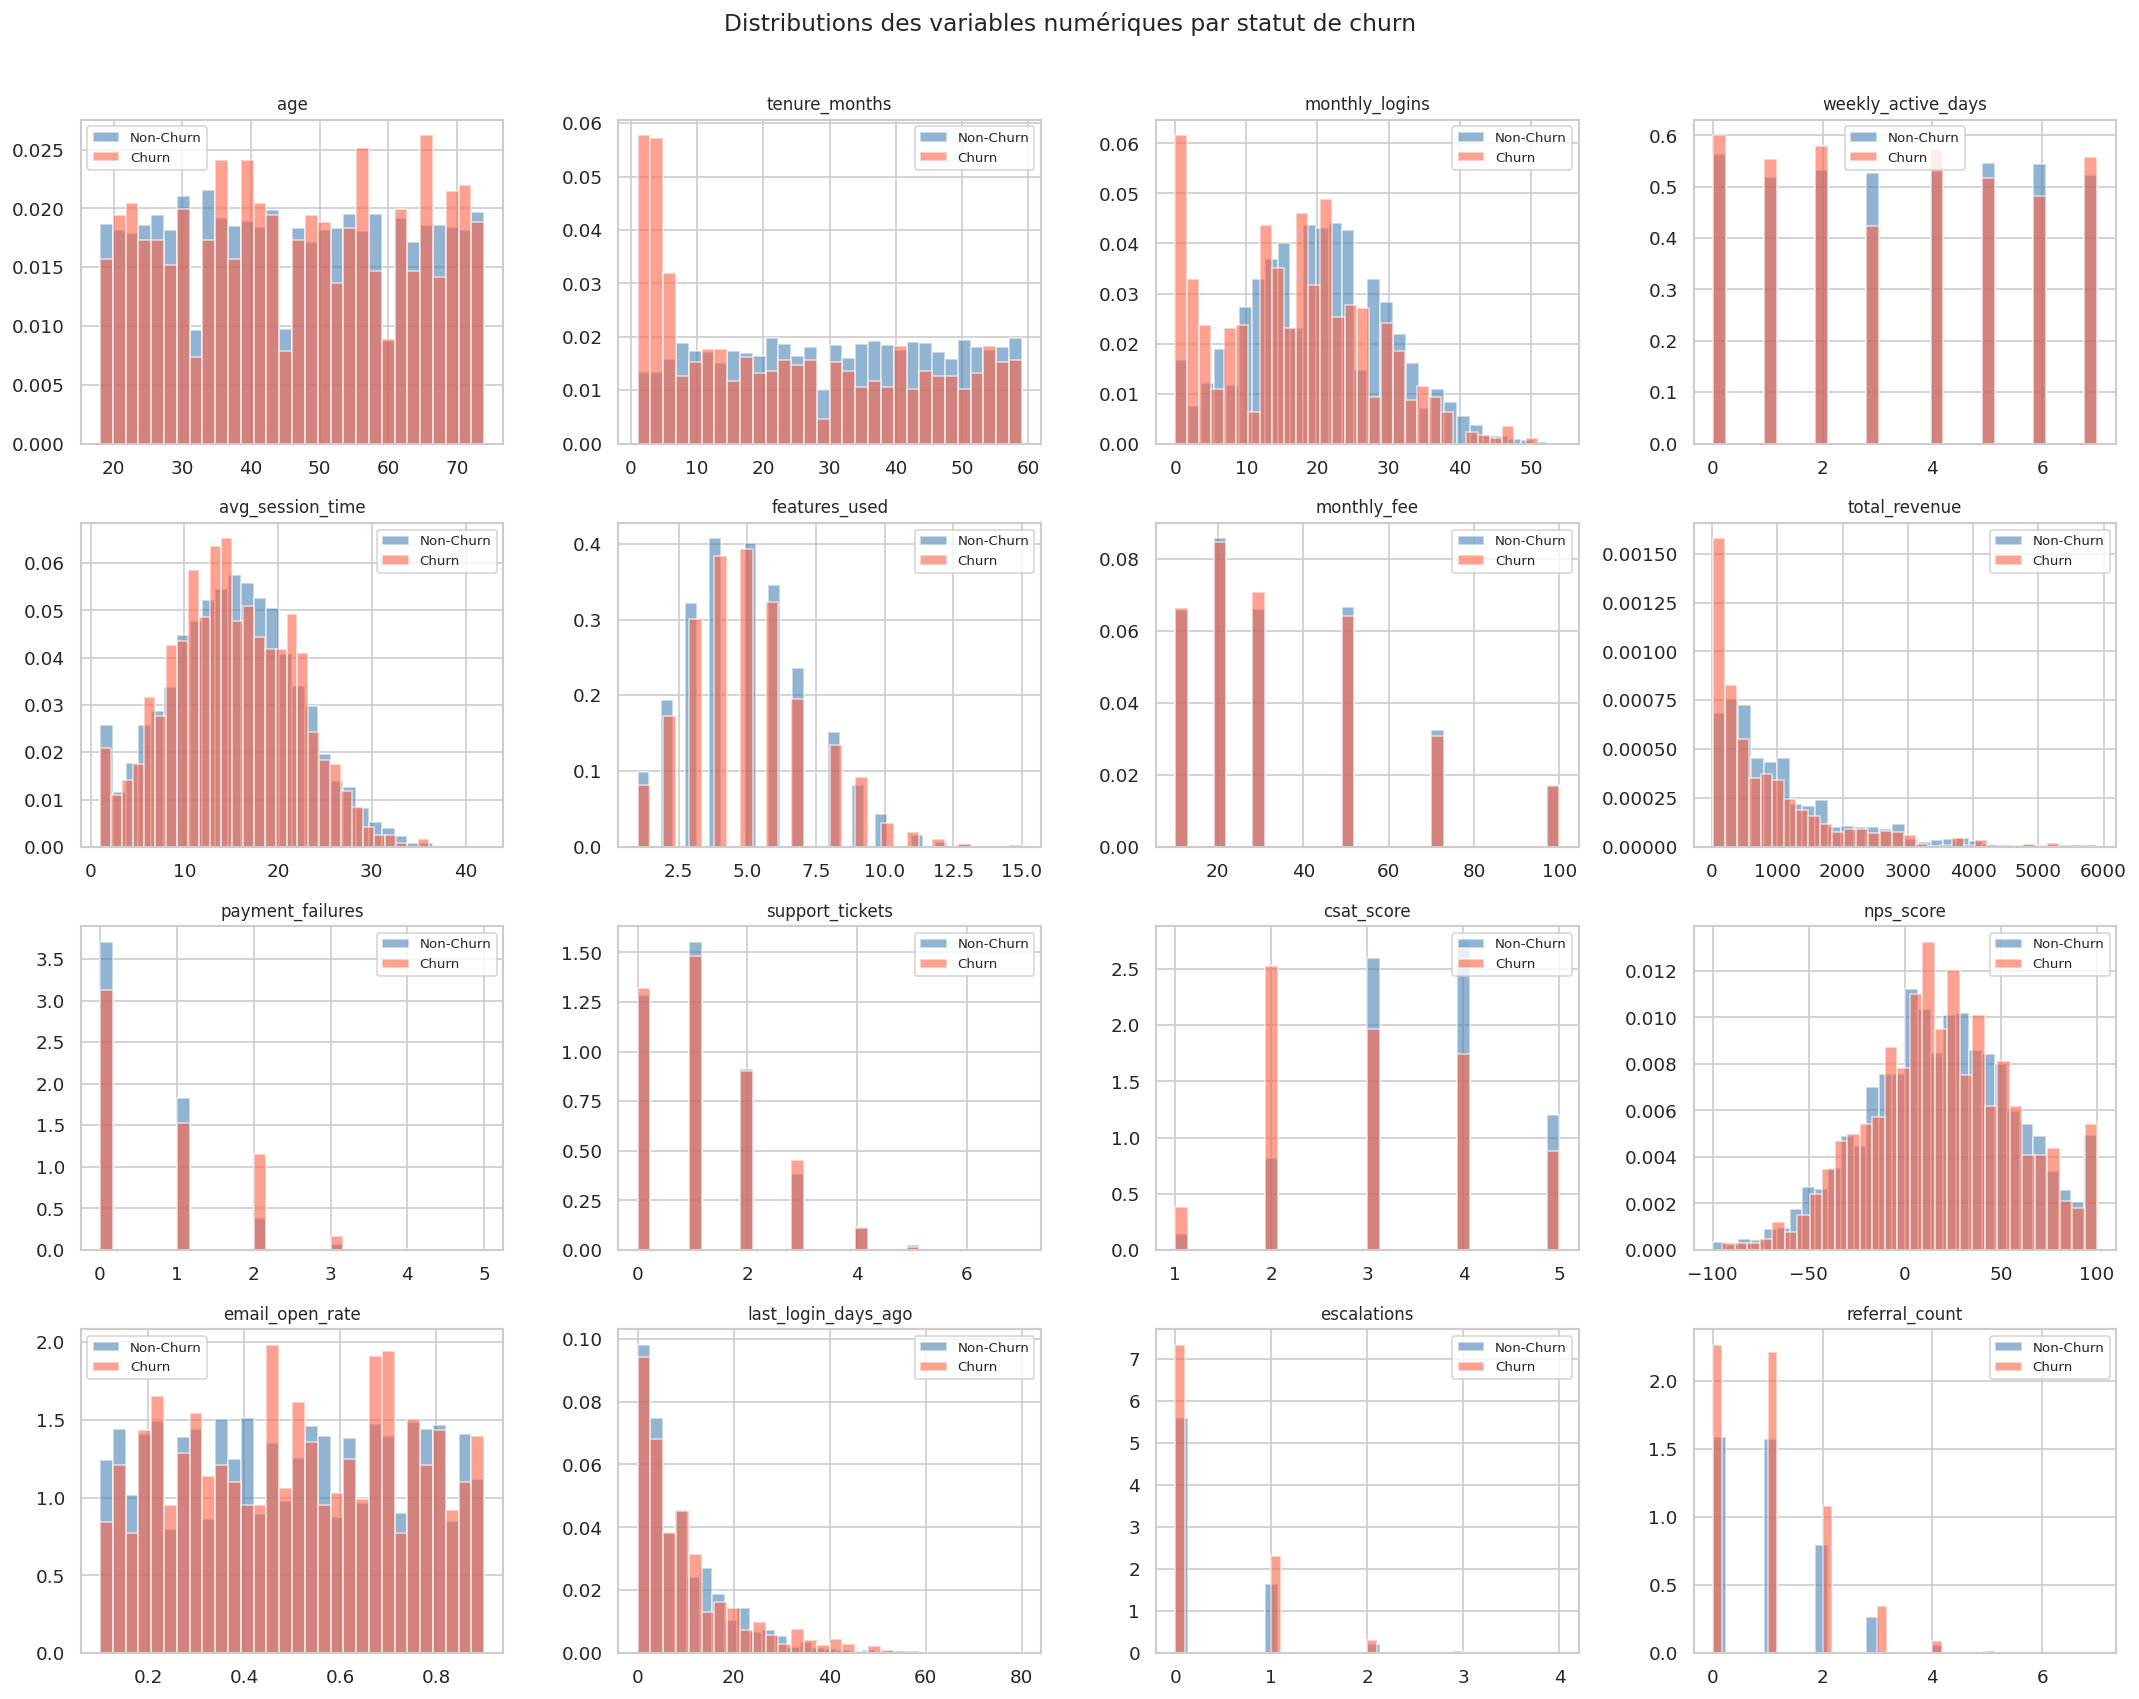

In [10]:
feature_groups = get_feature_groups()

# On affiche les distributions pour chaque groupe de variables numériques
# en distinguant les churners des non-churners. Les différences visuelles
# donnent une première intuition des features discriminantes.
num_cols = [
    'age', 'tenure_months', 'monthly_logins', 'weekly_active_days',
    'avg_session_time', 'features_used', 'monthly_fee', 'total_revenue',
    'payment_failures', 'support_tickets', 'csat_score', 'nps_score',
    'email_open_rate', 'last_login_days_ago', 'escalations', 'referral_count'
]

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, color, label in [(0, 'steelblue', 'Non-Churn'), (1, 'tomato', 'Churn')]:
        data = df[df['churn'] == churn_val][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des variables numériques par statut de churn', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/processed/fig_numeric_distributions.png', bbox_inches='tight')
plt.show()

In [ ]:
# Test statistique de Mann-Whitney U pour quantifier les différences.
# Ce test non paramétrique est adapté car les distributions ne sont pas
# nécessairement normales.
from scipy import stats

results = []
for col in num_cols:
    group0 = df[df['churn'] == 0][col].dropna()
    group1 = df[df['churn'] == 1][col].dropna()
    stat, pval = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    mean_diff = group1.mean() - group0.mean()
    results.append({'feature': col, 'p_value': pval, 'mean_diff_churn_vs_no': mean_diff})

results_df = pd.DataFrame(results).sort_values('p_value')
results_df['significant'] = results_df['p_value'] < 0.05
display(results_df.round(4))
print(f"\nFeatures significatives (p<0.05) : {results_df['significant'].sum()}/{len(num_cols)}")

## 4. Variables catégorielles — taux de churn par modalité

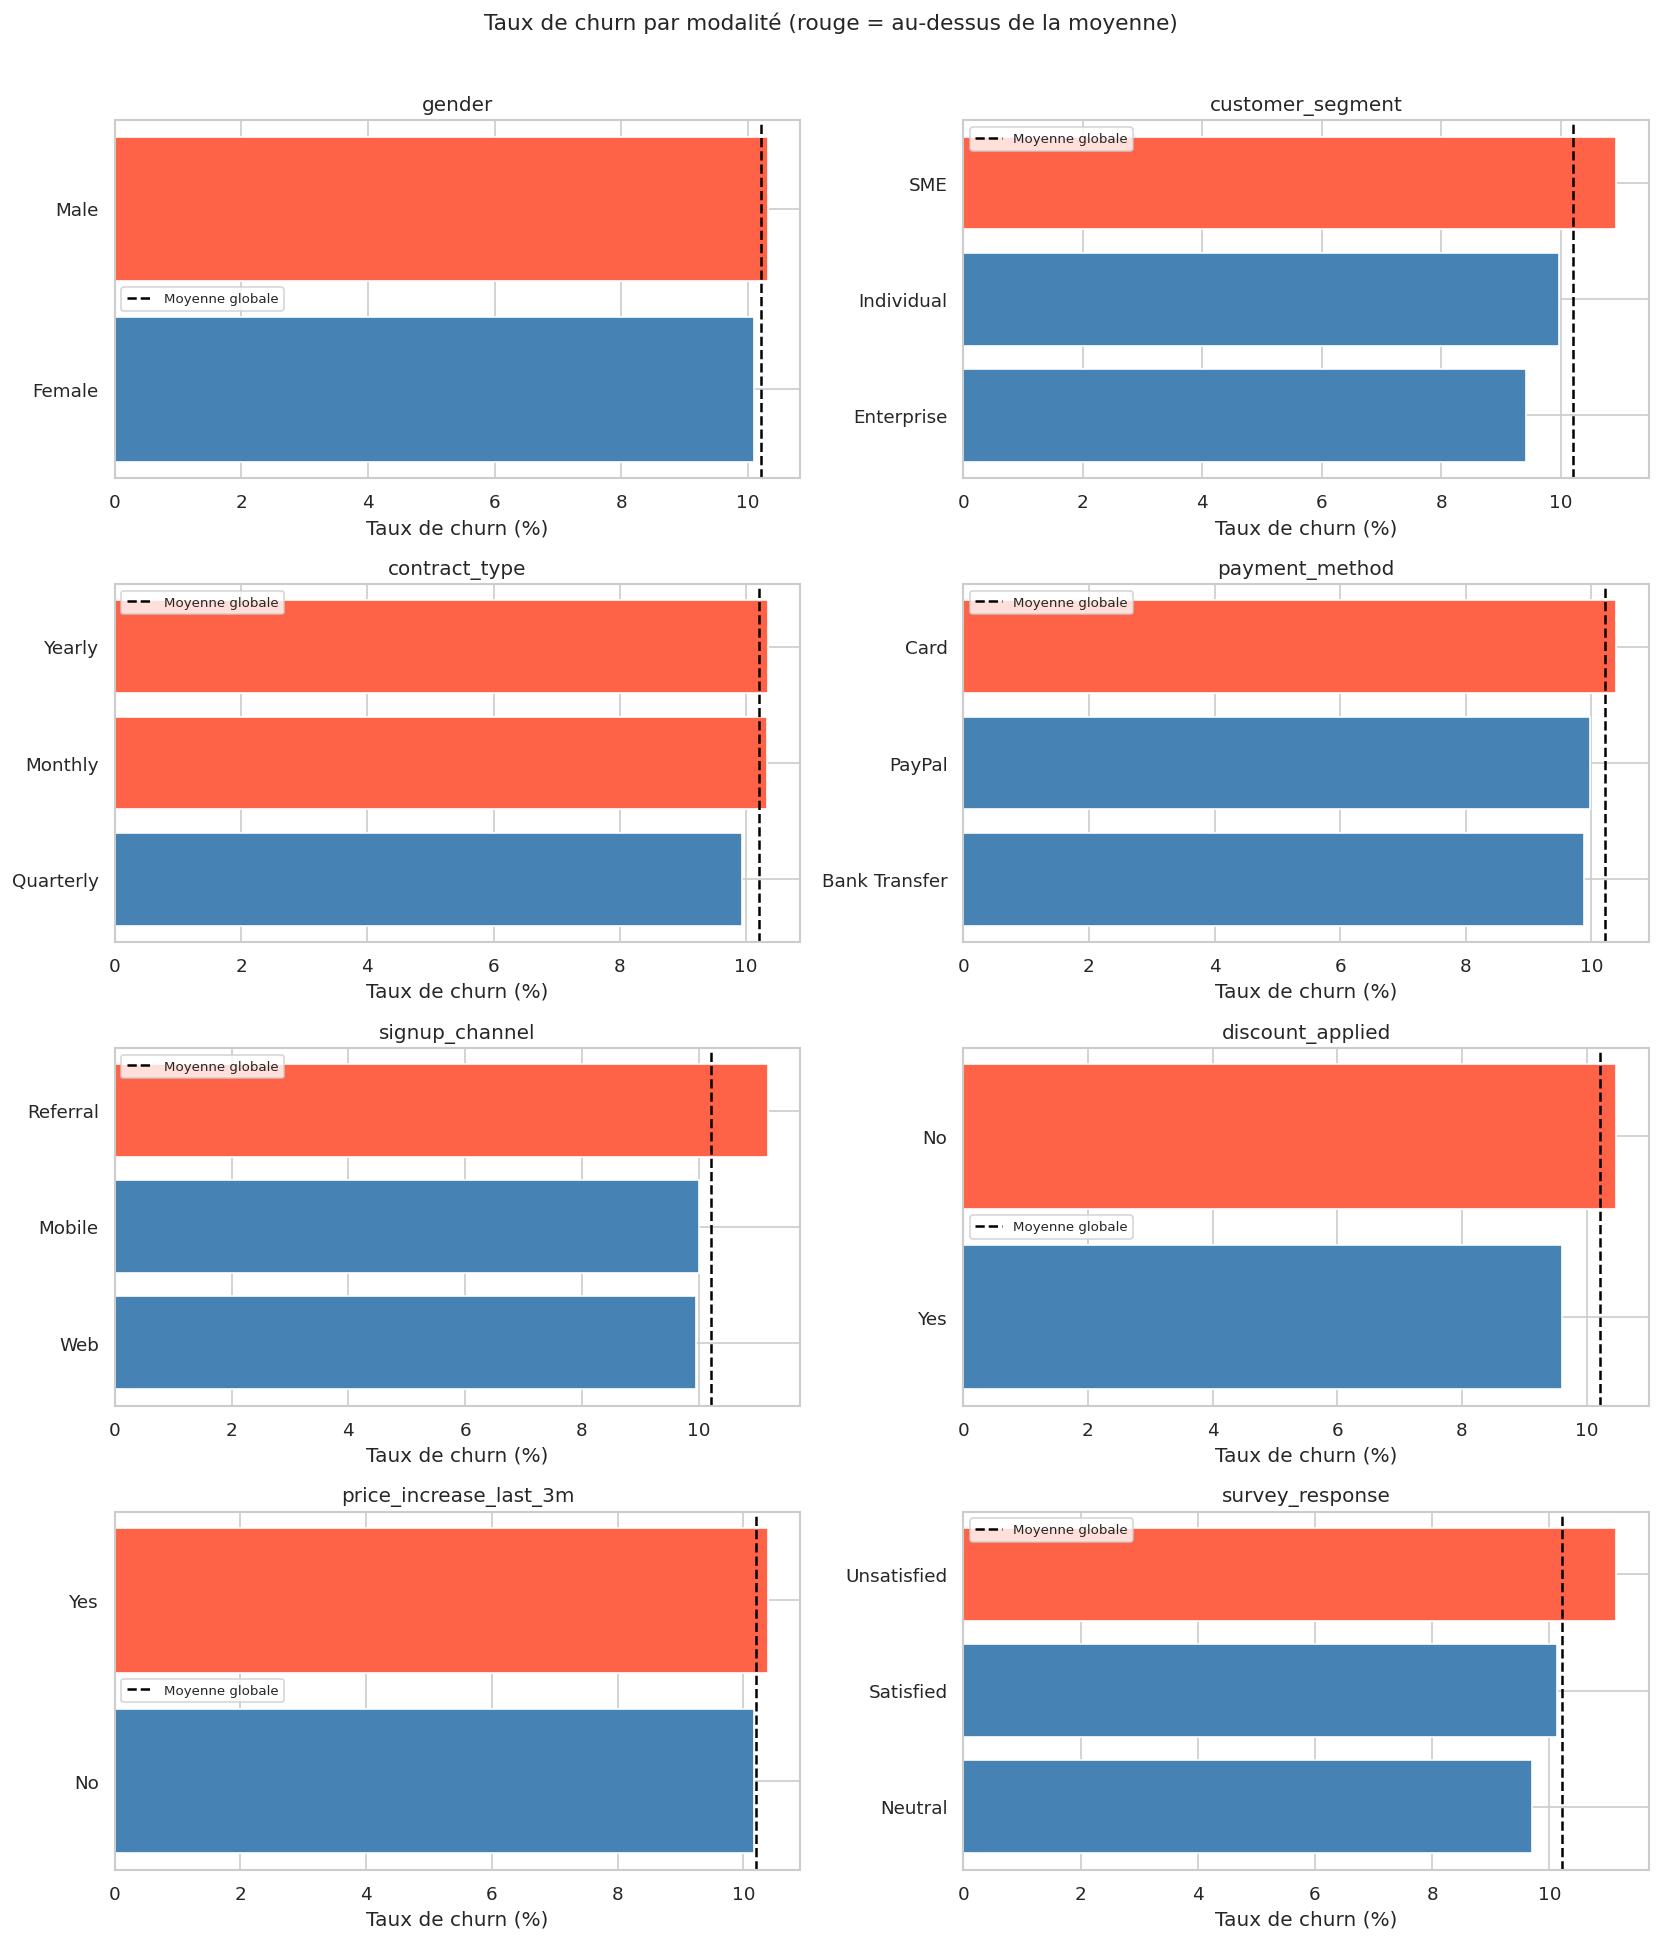

In [11]:
cat_cols = ['gender', 'customer_segment', 'contract_type', 'payment_method',
            'signup_channel', 'discount_applied', 'price_increase_last_3m', 'survey_response']

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=True)
    colors = ['tomato' if v > df['churn'].mean() else 'steelblue' for v in churn_rate.values]
    axes[i].barh(churn_rate.index, churn_rate.values * 100, color=colors)
    axes[i].axvline(df['churn'].mean() * 100, color='black', linestyle='--', lw=1.5, label='Moyenne globale')
    axes[i].set_xlabel('Taux de churn (%)')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Taux de churn par modalité (rouge = au-dessus de la moyenne)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('data/processed/fig_categorical_churn_rates.png', bbox_inches='tight')
plt.show()

## 5. Matrice de corrélation

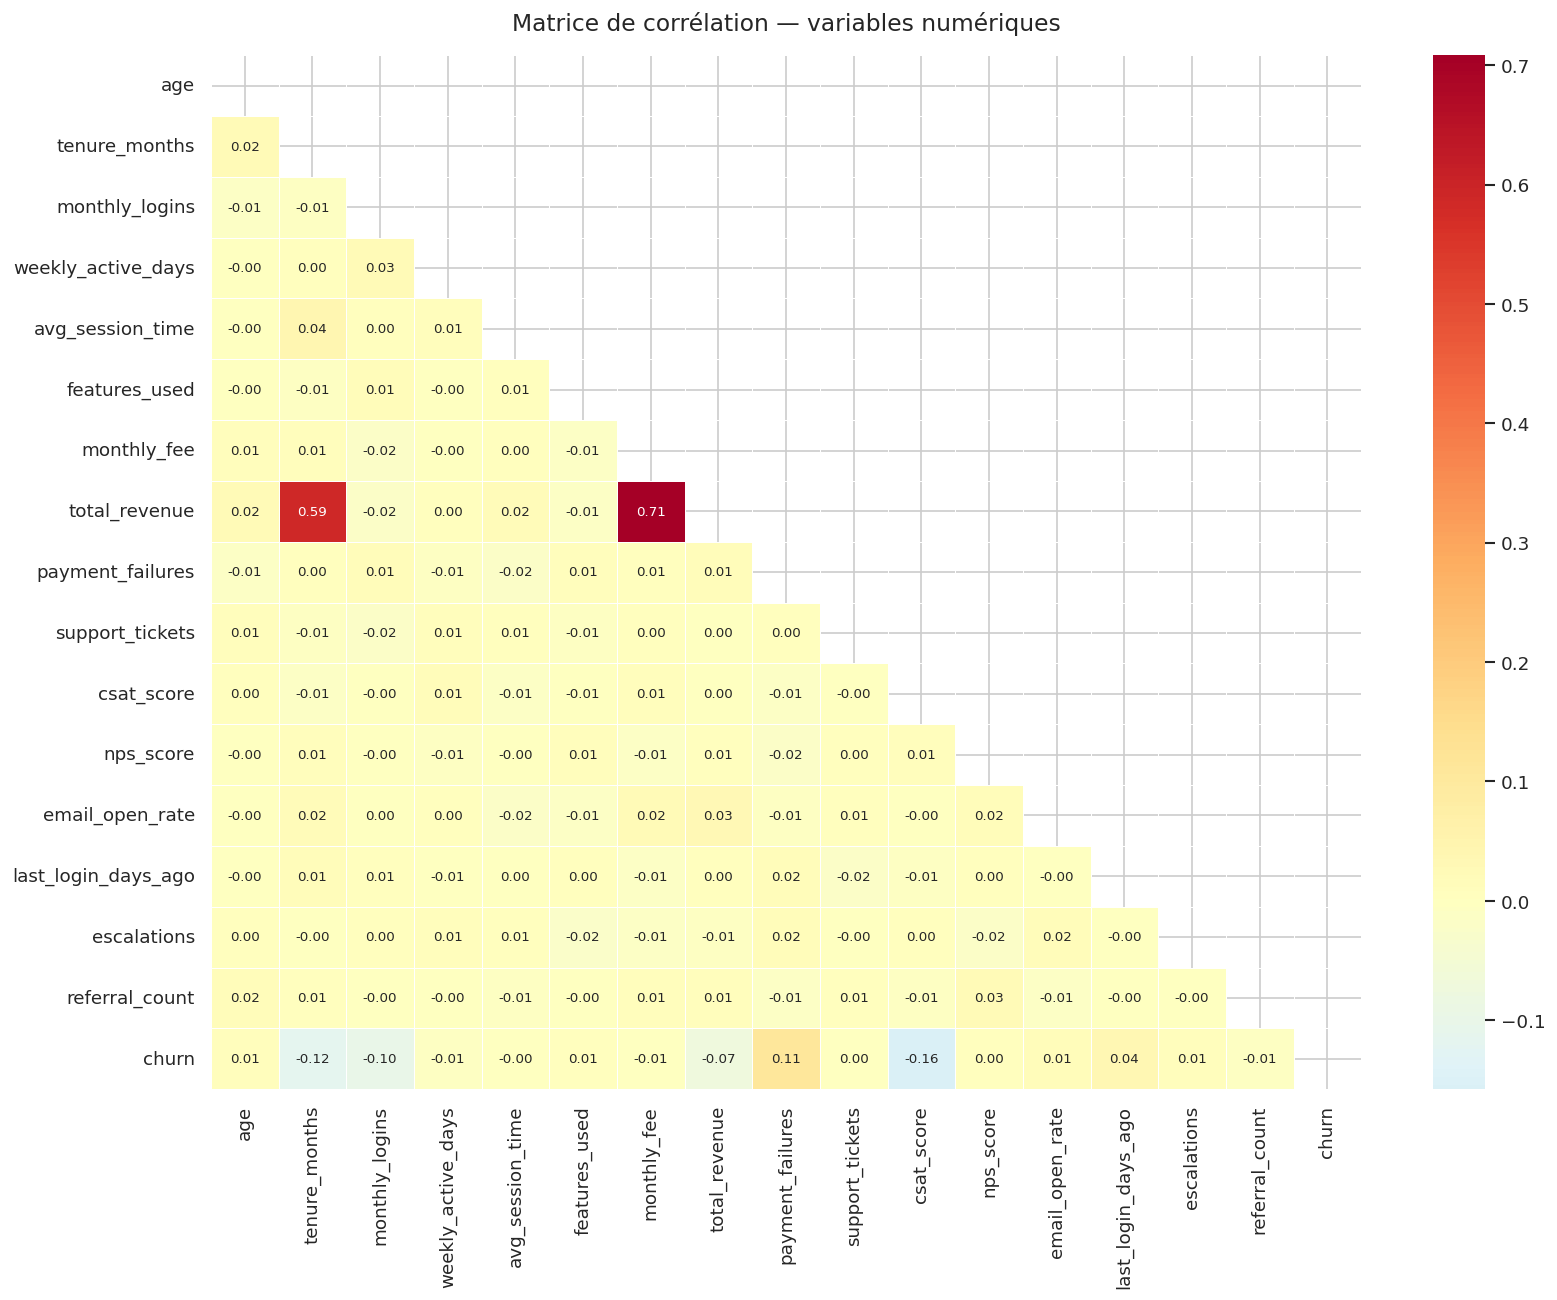

Top 10 corrélations avec le churn :
csat_score             0.158
tenure_months          0.117
payment_failures       0.112
monthly_logins         0.098
total_revenue          0.070
last_login_days_ago    0.037
email_open_rate        0.012
age                    0.010
escalations            0.010
weekly_active_days     0.009
Name: churn, dtype: float64


In [12]:
corr_cols = num_cols + ['churn']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Matrice de corrélation — variables numériques', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('data/processed/fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Corrélations les plus fortes avec le churn
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
print("Top 10 corrélations avec le churn :")
print(churn_corr.head(10).round(3))

## 6. Analyse des variables financières

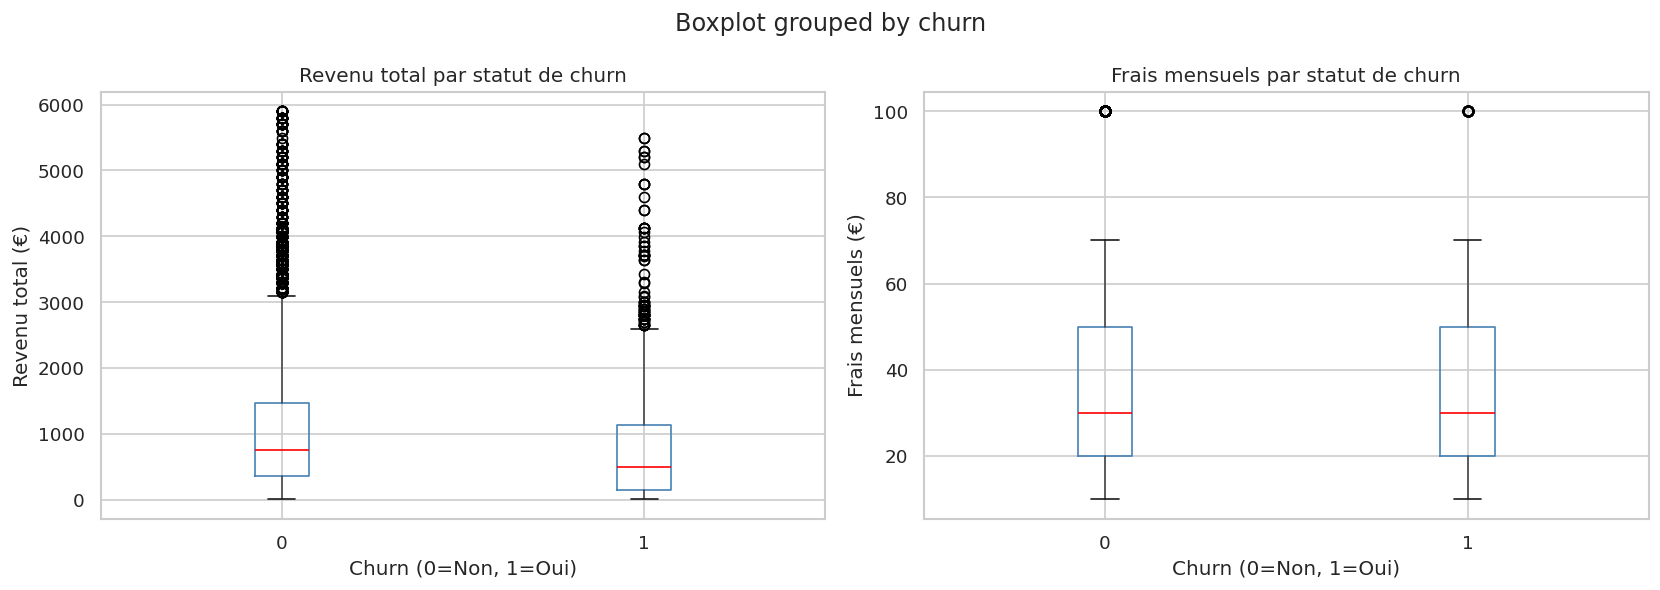

Revenu total des churners : 862,640 €
Frais mensuels perdus si tous churnent : 35,300 € / mois
Part du revenu total exposée : 8.2%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenu total par statut churn
df.boxplot(column='total_revenue', by='churn', ax=axes[0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[0].set_title('Revenu total par statut de churn')
axes[0].set_xlabel('Churn (0=Non, 1=Oui)')
axes[0].set_ylabel('Revenu total (€)')
plt.sca(axes[0])
plt.title('Revenu total par statut de churn')

# Frais mensuels par statut churn
df.boxplot(column='monthly_fee', by='churn', ax=axes[1],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[1].set_title('Frais mensuels par statut de churn')
axes[1].set_xlabel('Churn (0=Non, 1=Oui)')
axes[1].set_ylabel('Frais mensuels (€)')
plt.sca(axes[1])
plt.title('Frais mensuels par statut de churn')

plt.tight_layout()
plt.savefig('data/processed/fig_financial_analysis.png', bbox_inches='tight')
plt.show()

# Estimation du revenu à risque si on ne fait rien
churners = df[df['churn'] == 1]
revenue_at_risk = churners['total_revenue'].sum()
monthly_risk = churners['monthly_fee'].sum()
print(f"Revenu total des churners : {revenue_at_risk:,.0f} €")
print(f"Frais mensuels perdus si tous churnent : {monthly_risk:,.0f} € / mois")
print(f"Part du revenu total exposée : {revenue_at_risk / df['total_revenue'].sum() * 100:.1f}%")

## 7. Profil type du client churner vs non-churner

In [14]:
profile_cols = [
    'age', 'tenure_months', 'monthly_logins', 'support_tickets',
    'payment_failures', 'nps_score', 'csat_score', 'total_revenue'
]

profile = df.groupby('churn')[profile_cols].mean().T
profile.columns = ['Non-Churn', 'Churn']
profile['difference_%'] = ((profile['Churn'] - profile['Non-Churn']) / profile['Non-Churn'] * 100).round(1)
display(profile.round(2))

,Non-Churn,Churn,difference_%
age,45.85,46.40,1.2
tenure_months,30.83,24.22,-21.4
monthly_logins,20.00,16.80,-16.0
support_tickets,1.21,1.21,0.1
payment_failures,0.47,0.74,55.8
nps_score,19.07,19.46,2.0
csat_score,3.54,3.03,-14.4
total_revenue,1081.14,844.90,-21.9


## 8. Synthèse — Points clés pour la modélisation

In [15]:
print("""
Points clés identifiés dans l'EDA :

1. Déséquilibre des classes : ~10% de churn. On utilisera class_weight='balanced'
   sur les modèles sklearn et une pondération dans la loss du MLP.

2. Une seule valeur manquante significative : complaint_type (~20% de NaN).
   Ces NaN sont informatifs (pas de plainte = client moins insatisfait).
   On les remplace par 'no_complaint' avant l'encodage.

3. Features les plus corrélées avec le churn :
   - support_tickets, payment_failures, escalations (signaux d'insatisfaction)
   - tenure_months (les clients récents churnent plus)
   - nps_score, csat_score (satisfaction directe)

4. Variables catégorielles à fort impact :
   - contract_type (mensuel vs annuel)
   - price_increase_last_3m
   - customer_segment

5. Pas de valeurs aberrantes extrêmes détectées, les données semblent
   cohérentes avec un dataset synthétique bien contrôlé.
""")


Points clés identifiés dans l'EDA :

1. Déséquilibre des classes : ~10% de churn. On utilisera class_weight='balanced'
   sur les modèles sklearn et une pondération dans la loss du MLP.

2. Une seule valeur manquante significative : complaint_type (~20% de NaN).
   Ces NaN sont informatifs (pas de plainte = client moins insatisfait).
   On les remplace par 'no_complaint' avant l'encodage.

3. Features les plus corrélées avec le churn :
   - support_tickets, payment_failures, escalations (signaux d'insatisfaction)
   - tenure_months (les clients récents churnent plus)
   - nps_score, csat_score (satisfaction directe)

4. Variables catégorielles à fort impact :
   - contract_type (mensuel vs annuel)
   - price_increase_last_3m
   - customer_segment

5. Pas de valeurs aberrantes extrêmes détectées, les données semblent
   cohérentes avec un dataset synthétique bien contrôlé.

